Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9225 - loss: 0.2663 - val_accuracy: 0.9549 - val_loss: 0.1463
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9640 - loss: 0.1190 - val_accuracy: 0.9642 - val_loss: 0.1145
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9753 - loss: 0.0812 - val_accuracy: 0.9681 - val_loss: 0.0997
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9820 - loss: 0.0590 - val_accuracy: 0.9737 - val_loss: 0.0834
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0465 - val_accuracy: 0.9748 - val_loss: 0.0812
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9887 - loss: 0.0361 - val_accuracy: 0.9767 - val_loss: 0.0812
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accuracy: 0.9773 - val_loss: 0.0798
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9929 - loss: 0.0233 -

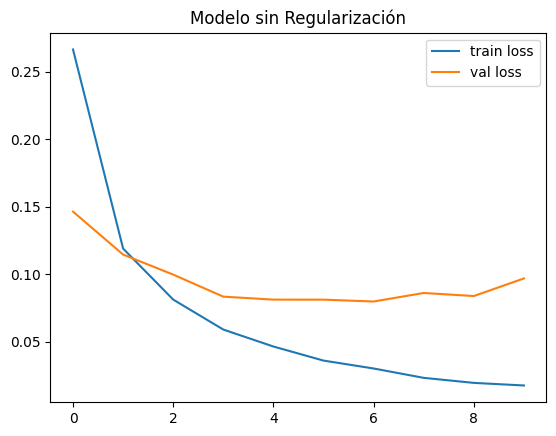

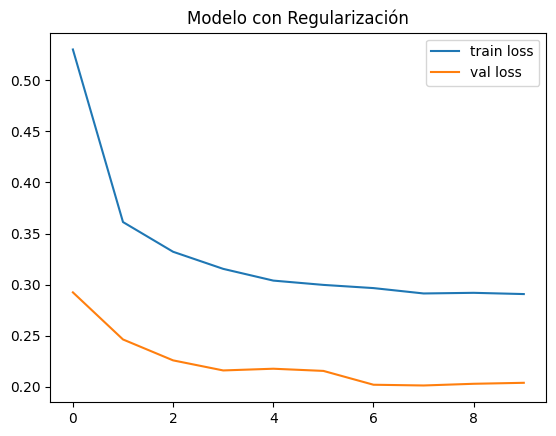


===== RESULTADOS MODELO SIN REGULARIZACIÓN =====
Train Loss: 0.0177
Train Accuracy: 0.9944
Validation Loss: 0.0969
Validation Accuracy: 0.9760
Diferencia Loss: 0.0792
Diferencia Accuracy: 0.0184

===== RESULTADOS MODELO CON REGULARIZACIÓN =====
Train Loss: 0.2907
Train Accuracy: 0.9411
Validation Loss: 0.2039
Validation Accuracy: 0.9683
Diferencia Loss: 0.0868
Diferencia Accuracy: 0.0272


In [5]:
# ==============================
# IMPORTACIÓN DE LIBRERÍAS
# ==============================

import tensorflow as tf  # Librería principal de machine learning
from tensorflow import keras  # API de alto nivel para crear modelos fácilmente
from tensorflow.keras import layers  # Contiene las capas de la red neuronal
import matplotlib.pyplot as plt  # Para graficar resultados


# ==============================
# CARGA Y PREPARACIÓN DE DATOS
# ==============================

# Carga el dataset MNIST (imágenes de números del 0 al 9)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normaliza los datos (los valores pasan de 0-255 a 0-1)
# Esto mejora el entrenamiento de la red
x_train = x_train / 255.0
x_test = x_test / 255.0


# ==============================
# MODELO SIN REGULARIZACIÓN
# ==============================

# Se crea un modelo secuencial (capa tras capa)
model_sin_reg = keras.Sequential([

    # Convierte la imagen de 28x28 en un vector de 784 valores
    layers.Flatten(input_shape=(28, 28)),

    # Capa densa con 128 neuronas y función de activación ReLU
    # Aquí la red aprende patrones de los datos
    layers.Dense(128, activation='relu'),

    # Capa de salida con 10 neuronas (una por cada número)
    # Softmax convierte la salida en probabilidades
    layers.Dense(10, activation='softmax')
])

# Compilación del modelo (configuración del aprendizaje)
model_sin_reg.compile(
    optimizer='adam',  # Algoritmo que ajusta los pesos automáticamente
    loss='sparse_categorical_crossentropy',  # Función de error para clasificación
    metrics=['accuracy']  # Métrica para evaluar qué tan bien predice
)

# Entrenamiento del modelo
history_sin = model_sin_reg.fit(
    x_train, y_train,  # Datos de entrenamiento
    epochs=10,  # Número de veces que el modelo ve todos los datos
    validation_data=(x_test, y_test)  # Datos para evaluar el modelo
)


# ==============================
# MODELO CON REGULARIZACIÓN
# ==============================

# Importa regularizadores (para evitar sobreajuste)
from tensorflow.keras import regularizers

# Se crea otro modelo, pero ahora con regularización
model_con_reg = keras.Sequential([

    # Convierte la imagen en vector
    layers.Flatten(input_shape=(28, 28)),

    # Capa densa con regularización L2
    # L2 penaliza pesos grandes para evitar que el modelo memorice
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    # Dropout apaga aleatoriamente el 50% de las neuronas en cada entrenamiento
    # Esto ayuda a que el modelo generalice mejor
    layers.Dropout(0.5),

    # Capa de salida
    layers.Dense(10, activation='softmax')
])

# Compilación del modelo
model_con_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo con regularización
history_con = model_con_reg.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)


# ==============================
# VISUALIZACIÓN DE RESULTADOS
# ==============================

# Función para graficar el comportamiento del modelo
def plot_history(history, title):

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(title)
    plt.legend()
    plt.show()


# Gráfica del modelo sin regularización
plot_history(history_sin, "Modelo sin Regularización")

# Gráfica del modelo con regularización
plot_history(history_con, "Modelo con Regularización")

# ==============================
# RESULTADOS NUMÉRICOS
# ==============================

print("\n===== RESULTADOS MODELO SIN REGULARIZACIÓN =====")

# Último valor de loss y accuracy en entrenamiento
train_loss_sin = history_sin.history['loss'][-1]
train_acc_sin = history_sin.history['accuracy'][-1]

# Último valor de loss y accuracy en validación
val_loss_sin = history_sin.history['val_loss'][-1]
val_acc_sin = history_sin.history['val_accuracy'][-1]

print(f"Train Loss: {train_loss_sin:.4f}")
print(f"Train Accuracy: {train_acc_sin:.4f}")
print(f"Validation Loss: {val_loss_sin:.4f}")
print(f"Validation Accuracy: {val_acc_sin:.4f}")

# Diferencia entre entrenamiento y validación (indicador de overfitting)
print(f"Diferencia Loss: {abs(train_loss_sin - val_loss_sin):.4f}")
print(f"Diferencia Accuracy: {abs(train_acc_sin - val_acc_sin):.4f}")


print("\n===== RESULTADOS MODELO CON REGULARIZACIÓN =====")

train_loss_con = history_con.history['loss'][-1]
train_acc_con = history_con.history['accuracy'][-1]

val_loss_con = history_con.history['val_loss'][-1]
val_acc_con = history_con.history['val_accuracy'][-1]

print(f"Train Loss: {train_loss_con:.4f}")
print(f"Train Accuracy: {train_acc_con:.4f}")
print(f"Validation Loss: {val_loss_con:.4f}")
print(f"Validation Accuracy: {val_acc_con:.4f}")

print(f"Diferencia Loss: {abs(train_loss_con - val_loss_con):.4f}")
print(f"Diferencia Accuracy: {abs(train_acc_con - val_acc_con):.4f}")